In [1]:
import sys
sys.path.insert(1, '../') # add to path a folder one layer upper, where we have something useful

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio

from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score
from statsmodels.stats.multitest import multipletests

### Functions

In [2]:
def count_sz_types(curr_lab, all_types = range(7)):
    _, counts = np.unique(np.concatenate([curr_lab,all_types]), return_counts=True)
    return counts-1

In [3]:
from sklearn.preprocessing import StandardScaler

def leave_oneSeizure_out(features,label):

    scaler = StandardScaler()

    nSz = len(label)
    labels_pred = np.ones_like(label)*(-7)

    for id in range(nSz):

        mask = np.arange(nSz) != id
        features_train = scaler.fit_transform(features[mask])
        features_test = scaler.transform(features[id].reshape(1, -1))
        labels_train = label[mask]

        clf = SVC(kernel='linear', class_weight='balanced') 

        clf.fit(features_train,labels_train)
        labels_pred[id] = clf.predict(features_test.reshape(1, -1))[0]

    return labels_pred


def leave_onePatient_out(features,label,patID):
    labels_pred = np.ones_like(label)*(-7)

    scaler = StandardScaler()
    for curID in patID:

        features_train = scaler.fit_transform(features[np.array(patID) != curID])
        labels_train = label[np.array(patID) != curID]
        features_test = scaler.transform(features[np.array(patID) == curID])

        clf = SVC(kernel='linear', class_weight='balanced')
        clf.fit(features_train,labels_train)
        labels_pred[np.array(patID) == curID] = clf.predict(features_test)
    
    return labels_pred

In [4]:
def compute_accuracy_leaveOutSeizure(features, labels,random_lables):
    
    labels_pred = leave_oneSeizure_out(features,labels)
    
    random_accuracy = [balanced_accuracy_score(random_lables[i],labels_pred) for i in range(len(random_lables))]
    actual_accuracy = balanced_accuracy_score(labels,labels_pred)
    return actual_accuracy, np.array(random_accuracy)


def compute_accuracy_leaveOutPatient(features, labels, patID,random_lables):
    labels_pred = leave_onePatient_out(features,labels,patID)

    random_accuracy = [balanced_accuracy_score(random_lables[i],labels_pred) for i in range(len(random_lables))]
    actual_accuracy = balanced_accuracy_score(labels,labels_pred)
    return actual_accuracy, np.array(random_accuracy)

## Data

### Load data

Load ABG values for different time points and channel types. 

In [5]:
mat_contents = sio.loadmat('../Service/ABGparameters_types/ABG_clean_detailedABG.mat')
A_soz = mat_contents['A_soz']
B_soz = mat_contents['B_soz']
G_soz = mat_contents['G_soz']

A_other = mat_contents['A_other']
B_other = mat_contents['B_other']
G_other = mat_contents['G_other']

A_all = mat_contents['A_all']
B_all = mat_contents['B_all']
G_all = mat_contents['G_all']

szOnsetType_original = np.array([mat_contents['szOnsetType_original'][0][k] for k in range(len(mat_contents['szOnsetType_original'][0]))])[:,0]

FileInfo = mat_contents['patID']
patID_all = [FileInfo[0][i][0] for i in range(FileInfo.shape[1])]

Turn original data labels (strings) into numbers

In [6]:
labels_original_all = szOnsetType_original
all_types_original = np.unique(labels_original_all)

labels_all = np.zeros(len(labels_original_all))
for i,tp in enumerate(all_types_original):
    labels_all[np.array(labels_original_all) == tp] = i


unique, counts = np.unique(labels_all, return_counts=True)
print(unique)
print(counts)

[0. 1. 2. 3. 4. 5. 6.]
[ 4 57 70 18 41 12  3]


### Data description

In [7]:
patID = patID_all
labels = labels_all

[ 4. 57. 70. 18. 41. 12.  3.]
[ 1.  8. 24.  6.  8. 27. 14. 21. 11.  6.  6. 20. 21. 13. 19.]


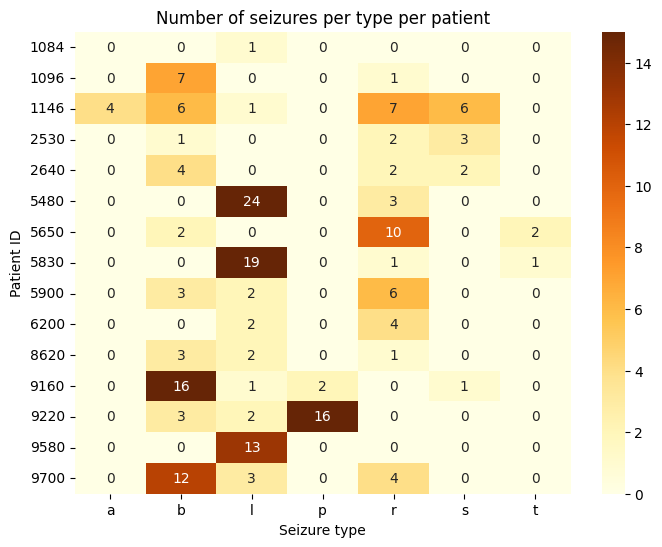

In [8]:
patSet = np.unique(patID)
nPat = len(patSet)
all_types = np.unique(labels)

nTypes = len(all_types)

sz_counts = np.zeros((nPat,nTypes))
for iP,pat in enumerate(patSet):
    curr_lab = labels_original_all[np.array(patID) == pat]
    sz_counts[iP] = count_sz_types(curr_lab, all_types=all_types_original)

print(sz_counts.sum(axis=0))
print(sz_counts.sum(axis=1))

plt.figure(figsize=(8,6))
sns.heatmap(sz_counts, annot=True, vmin=0, vmax=15, cmap="YlOrBr", yticklabels=patSet, xticklabels=all_types_original)#vmin=0, vmax=0.05, fmt=".2f",

plt.title("Number of seizures per type per patient")
plt.ylabel('Patient ID')
plt.xlabel('Seizure type')
plt.show()

## Data analysis/classification

### Setup

Prepare all the feature dictionaries from the A,B,G values for different time points and channel types.
- Channel types: SOZ/Other/All
- Time points: [Interictal, Preictal, Onset, Seizure]
- 'Trajectory': All time points taken as vector

In [9]:
features_all = {}
features_all['SOZ'],features_all['Other'],features_all['All'] = {},{},{}

features_all['SOZ']['Trajectory'] = np.concatenate([A_soz[:,:].T, B_soz[:,:].T, G_soz[:,:].T]).T
features_all['SOZ']['Interictal'] = np.concatenate([A_soz[:,0:1].T, B_soz[:,0:1].T, G_soz[:,0:1].T]).T
features_all['SOZ']['Preictal'] = np.concatenate([A_soz[:,1:2].T, B_soz[:,1:2].T, G_soz[:,1:2].T]).T
features_all['SOZ']['Onset'] = np.concatenate([A_soz[:,2:3].T, B_soz[:,2:3].T, G_soz[:,2:3].T]).T
features_all['SOZ']['Seizure'] = np.concatenate([A_soz[:,3:].T, B_soz[:,3:].T, G_soz[:,3:].T]).T

features_all['Other']['Trajectory'] = np.concatenate([A_other[:,:].T, B_other[:,:].T, G_other[:,:].T]).T
features_all['Other']['Interictal'] = np.concatenate([A_other[:,0:1].T, B_other[:,0:1].T, G_other[:,0:1].T]).T
features_all['Other']['Preictal'] = np.concatenate([A_other[:,1:2].T, B_other[:,1:2].T, G_other[:,1:2].T]).T
features_all['Other']['Onset'] = np.concatenate([A_other[:,2:3].T, B_other[:,2:3].T, G_other[:,2:3].T]).T
features_all['Other']['Seizure'] = np.concatenate([A_other[:,3:].T, B_other[:,3:].T, G_other[:,3:].T]).T

features_all['All']['Trajectory'] = np.concatenate([A_all[:,:].T, B_all[:,:].T, G_all[:,:].T]).T
features_all['All']['Interictal'] = np.concatenate([A_all[:,0:1].T, B_all[:,0:1].T, G_all[:,0:1].T]).T
features_all['All']['Preictal'] = np.concatenate([A_all[:,1:2].T, B_all[:,1:2].T, G_all[:,1:2].T]).T
features_all['All']['Onset'] = np.concatenate([A_all[:,2:3].T, B_all[:,2:3].T, G_all[:,2:3].T]).T
features_all['All']['Seizure'] = np.concatenate([A_all[:,3:].T, B_all[:,3:].T, G_all[:,3:].T]).T

In [10]:
features_A = {}
features_A['SOZ'],features_A['Other'],features_A['All'] = {},{},{}

features_A['SOZ']['Trajectory'] = A_soz[:,:]
features_A['SOZ']['Interictal'] = A_soz[:,0:1]
features_A['SOZ']['Preictal'] = A_soz[:,1:2]
features_A['SOZ']['Onset'] = A_soz[:,2:3]
features_A['SOZ']['Seizure'] = A_soz[:,3:]

features_A['Other']['Trajectory'] = A_other[:,:]
features_A['Other']['Interictal'] = A_other[:,0:1]
features_A['Other']['Preictal'] = A_other[:,1:2]
features_A['Other']['Onset'] = A_other[:,2:3]
features_A['Other']['Seizure'] = A_other[:,3:]

features_A['All']['Trajectory'] = A_all[:,:]
features_A['All']['Interictal'] = A_all[:,0:1]
features_A['All']['Preictal'] = A_all[:,1:2]
features_A['All']['Onset'] = A_all[:,2:3]
features_A['All']['Seizure'] = A_all[:,3:]

In [11]:
features_B = {}
features_B['SOZ'],features_B['Other'],features_B['All'] = {},{},{}

features_B['SOZ']['Trajectory'] = B_soz[:,:]
features_B['SOZ']['Interictal'] = B_soz[:,0:1]
features_B['SOZ']['Preictal'] = B_soz[:,1:2]
features_B['SOZ']['Onset'] = B_soz[:,2:3]
features_B['SOZ']['Seizure'] = B_soz[:,3:]

features_B['Other']['Trajectory'] = B_other[:,:]
features_B['Other']['Interictal'] = B_other[:,0:1]
features_B['Other']['Preictal'] = B_other[:,1:2]
features_B['Other']['Onset'] = B_other[:,2:3]
features_B['Other']['Seizure'] = B_other[:,3:]

features_B['All']['Trajectory'] = B_all[:,:]
features_B['All']['Interictal'] = B_all[:,0:1]
features_B['All']['Preictal'] = B_all[:,1:2]
features_B['All']['Onset'] = B_all[:,2:3]
features_B['All']['Seizure'] = B_all[:,3:]

In [12]:
features_G = {}
features_G['SOZ'],features_G['Other'],features_G['All'] = {},{},{}

features_G['SOZ']['Trajectory'] = G_soz[:,:]
features_G['SOZ']['Interictal'] = G_soz[:,0:1]
features_G['SOZ']['Preictal'] = G_soz[:,1:2]
features_G['SOZ']['Onset'] = G_soz[:,2:3]
features_G['SOZ']['Seizure'] = G_soz[:,3:]

features_G['Other']['Trajectory'] = G_other[:,:]
features_G['Other']['Interictal'] = G_other[:,0:1]
features_G['Other']['Preictal'] = G_other[:,1:2]
features_G['Other']['Onset'] = G_other[:,2:3]
features_G['Other']['Seizure'] = G_other[:,3:]

features_G['All']['Trajectory'] = G_all[:,:]
features_G['All']['Interictal'] = G_all[:,0:1]
features_G['All']['Preictal'] = G_all[:,1:2]
features_G['All']['Onset'] = G_all[:,2:3]
features_G['All']['Seizure'] = G_all[:,3:]

In [13]:
# Mix all labels irrespective of the patient
nSim = 500
nSz_all = len(labels_all)
random_lables_all = {} 
for i in range(nSim):
    random_lables_all[i] = labels_all[np.random.permutation(range(nSz_all))]

## Classification

### Leave one SEIZURE out

Prepare setup for classification based on all the types and only the selected types.

In [14]:
labels = labels_all
random_lables = random_lables_all

setup = {}
featSet = [features_all, features_A, features_B, features_G]
markSet = ['ABG','A','B','G']
for iF in range(4):
    setup['7 types, '+markSet[iF]] = {
        'types': 7,
        'parameters': markSet[iF],
        'labels': labels_all,
        'patID': patID_all,
        'random_lables': random_lables_all,
        'features': featSet[iF]
    }

For every channel type and time point, we can compute the accuracy of the classification and compare it to the distribution of accuracies obtained by chance (by shuffling the labels). This is repeated for all three parameters (ABG) and for every of the parameters separately.

In [15]:
classification_results = pd.DataFrame(columns=['Channels','Time mark','Accuracy','p-value','Number of types', 'Parameters'])

for time_mark in ['Trajectory','Interictal','Preictal','Onset','Seizure']:
    print(time_mark)
    for channels in ['All','SOZ','Other']:
        print(channels)
    
        for setup_mark in list(setup.keys()):
            actual_accuracy_value,accuracy_distribution = compute_accuracy_leaveOutSeizure(
                                                            setup[setup_mark]['features'][channels][time_mark],
                                                            setup[setup_mark]['labels'],
                                                            setup[setup_mark]['random_lables'])
            pv = (1 + np.sum(accuracy_distribution>=actual_accuracy_value)) /len(accuracy_distribution)
            classification_results.loc[len(classification_results)] = [channels, time_mark, actual_accuracy_value, pv, 
                                                                setup[setup_mark]['types'], setup[setup_mark]['parameters']]

Trajectory
All
SOZ
Other
Interictal
All
SOZ
Other
Preictal
All
SOZ
Other
Onset
All
SOZ
Other
Seizure
All
SOZ
Other


Define orders of time points, channels and parameters in dataFrame for the following plotting.

In [16]:
# Define custom orders
time_order = ['Trajectory', 'Interictal', 'Preictal', 'Onset', 'Seizure']
channel_order = ['All', 'SOZ', 'Other']
parameters_order = ['ABG','A','B','G']

# Convert the dataframe columns to Categorical with the specific order
classification_results['Time mark'] = pd.Categorical(
    classification_results['Time mark'], 
    categories=time_order, 
    ordered=True
)

classification_results['Channels'] = pd.Categorical(
    classification_results['Channels'], 
    categories=channel_order, 
    ordered=True
)

Compute the Benjamini-Hochberg FDR correction, accounting for multiple comparison. 

In [17]:
# 1. Initialize new columns for the corrections
classification_results['p-val FDR (BH)'] = 1.0
classification_results['Significant (FDR)'] = False

# 2. Iterate through each parameter set to correct within the group
for param in ['ABG', 'A', 'B', 'G']:
    # Create a mask for the current parameter set
    mask = classification_results['Parameters'] == param
    
    # Get the raw p-values for this group
    raw_p_values = classification_results.loc[mask, 'p-value'].values
    
    # --- FDR Correction (Benjamini-Hochberg) ---
    # Usually preferred in classification studies for better power
    rejected_fdr, p_fdr, _, _ = multipletests(raw_p_values, alpha=0.05, method='fdr_bh')
    
    # 3. Assign the results back to the DataFrame
    classification_results.loc[mask, 'p-val FDR (BH)'] = p_fdr
    classification_results.loc[mask, 'Significant (FDR)'] = rejected_fdr

Storing the results for plotting.

In [18]:
tables_accuracy, tables_unc_p, tables_dfr_p = {},{},{}
nTypes = 7
for param in ['ABG', 'A', 'B', 'G']:
    tables_accuracy[str(nTypes) + ' types, ' + param] = classification_results[
        (classification_results['Parameters'] == param) & 
        (classification_results['Number of types'] == nTypes)
        ].pivot(
            index='Channels', columns='Time mark', values='Accuracy'
        )

    tables_unc_p[str(nTypes) + ' types, ' + param] = classification_results[
        (classification_results['Parameters'] == param) & 
        (classification_results['Number of types'] == nTypes)
        ].pivot(
        index='Channels', columns='Time mark', values='p-value'
        )
    
    tables_dfr_p[str(nTypes) + ' types, ' + param] = classification_results[
        (classification_results['Parameters'] == param) & 
        (classification_results['Number of types'] == nTypes)
        ].pivot(
        index='Channels', columns='Time mark', values='p-val FDR (BH)'
        )

Plot the accuracy tables.

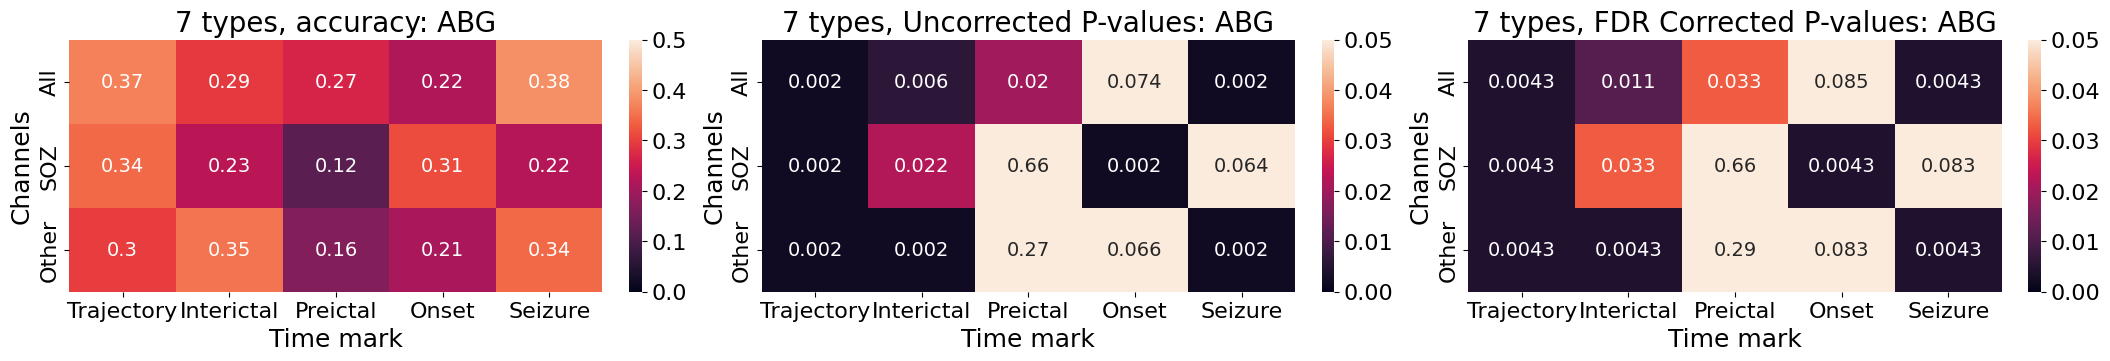

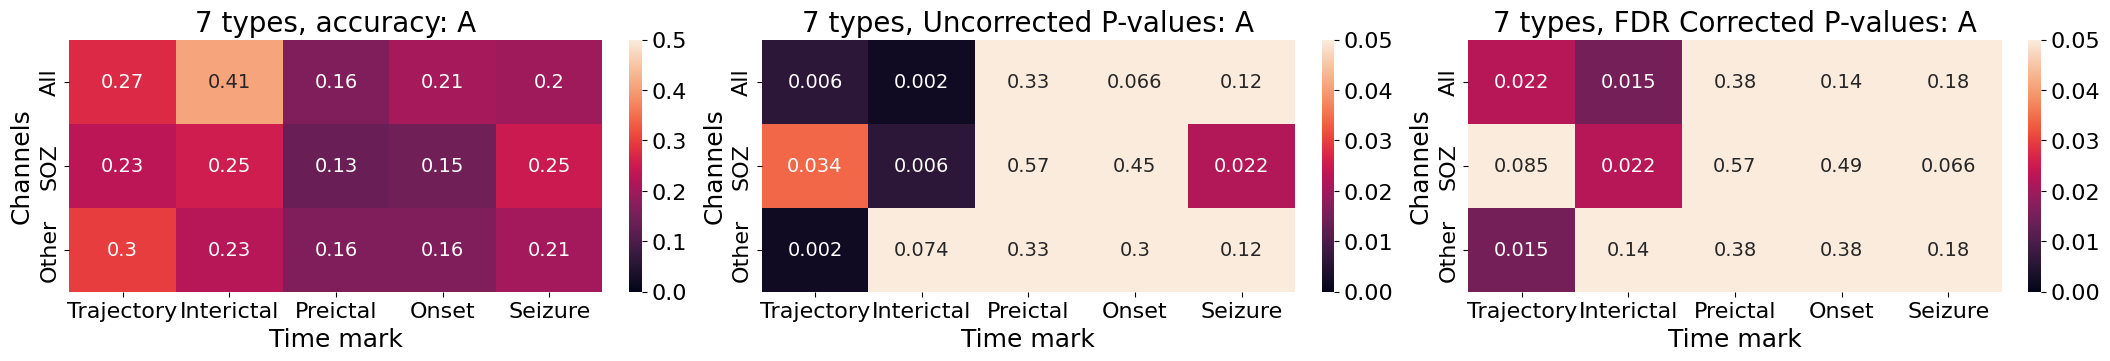

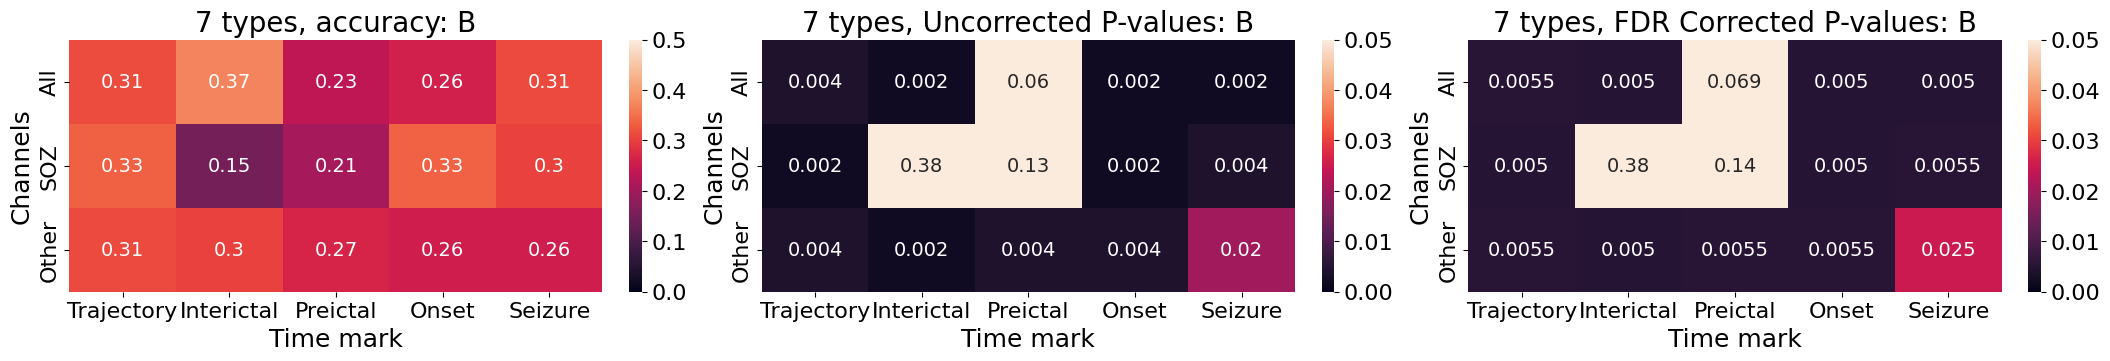

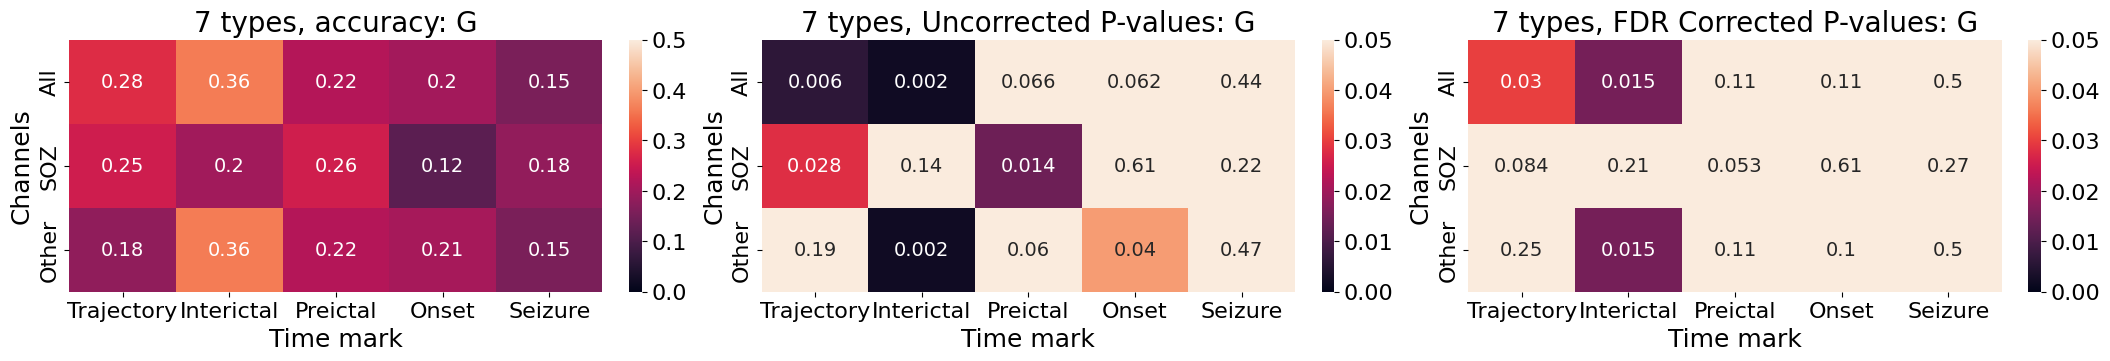

In [19]:
plt.rcParams.update({
    'font.size': 16,          # General font size (labels/ticks)
    'axes.titlesize': 20,      # Title size
    'axes.labelsize': 18,      # Axis labels size
    'xtick.labelsize': 16,     # X-axis tick labels
    'ytick.labelsize': 16      # Y-axis tick labels
})

nTypes = 7
for param in ['ABG', 'A', 'B', 'G']:
    fig = plt.figure(figsize=(21, 3.5), constrained_layout=True)
    grid = fig.add_gridspec(1, 3)

    ax1 = fig.add_subplot(grid[0,0])
    sns.heatmap(tables_accuracy[str(nTypes) + ' types, ' + param], annot=True,  vmin = 0, vmax=0.5, 
                annot_kws={"size": 14}) 
    plt.title(str(nTypes) + " types, accuracy: " + param)

    ax1 = fig.add_subplot(grid[0,1])
    sns.heatmap(tables_unc_p[str(nTypes) + ' types, ' + param], annot=True,  vmin = 0, vmax=0.05, 
                annot_kws={"size": 14}) 
    plt.title(str(nTypes) + " types, Uncorrected P-values: " + param)

    ax1 = fig.add_subplot(grid[0,2])
    sns.heatmap(tables_dfr_p[str(nTypes) + ' types, ' + param], annot=True,  vmin = 0, vmax=0.05, 
                annot_kws={"size": 14}) 
    plt.title(str(nTypes) + " types, FDR Corrected P-values: " + param)
    mark = str(nTypes) + 'types_' + param
    plt.savefig('../Pictures/Patterns/Classification_tables_'+mark+'.svg')
    plt.savefig('../Pictures/Patterns/Classification_tables_'+mark+'.png')
    plt.show()

### Leave one PATIENT out

This part repeats the previous one except the way how the classification is computed; in this part, CV with leave one patient out strategy is performed.

In [20]:
labels = labels_all
random_lables = random_lables_all

setup = {}
featSet = [features_all, features_A, features_B, features_G]
markSet = ['ABG','A','B','G']
for iF in range(4):
    setup['7 types, '+markSet[iF]] = {
        'types': 7,
        'parameters': markSet[iF],
        'labels': labels_all,
        'patID': patID_all,
        'random_lables': random_lables_all,
        'features': featSet[iF]
    }


In [21]:
classification_results = pd.DataFrame(columns=['Channels','Time mark','Accuracy','p-value','Number of types', 'Parameters'])

for time_mark in ['Trajectory','Interictal','Preictal','Onset','Seizure']:
    print(time_mark)
    for channels in ['All','SOZ','Other']:
        print(channels)
    
        for setup_mark in list(setup.keys()):
            actual_accuracy_value,accuracy_distribution = compute_accuracy_leaveOutPatient(
                                                            setup[setup_mark]['features'][channels][time_mark],
                                                            setup[setup_mark]['labels'],
                                                            setup[setup_mark]['patID'],
                                                            setup[setup_mark]['random_lables'])
            pv = (1 + np.sum(accuracy_distribution>=actual_accuracy_value)) /len(accuracy_distribution)
            classification_results.loc[len(classification_results)] = [channels, time_mark, actual_accuracy_value, pv, 
                                                                setup[setup_mark]['types'], setup[setup_mark]['parameters']]

Trajectory
All
SOZ
Other
Interictal
All
SOZ
Other
Preictal
All
SOZ
Other
Onset
All
SOZ
Other
Seizure
All
SOZ
Other


In [22]:
# 1. Define your custom orders
time_order = ['Trajectory', 'Interictal', 'Preictal', 'Onset', 'Seizure']
channel_order = ['All', 'SOZ', 'Other']
parameters_order = ['ABG','A','B','G']

# 2. Convert the dataframe columns to Categorical with the specific order
classification_results['Time mark'] = pd.Categorical(
    classification_results['Time mark'], 
    categories=time_order, 
    ordered=True
)

classification_results['Channels'] = pd.Categorical(
    classification_results['Channels'], 
    categories=channel_order, 
    ordered=True
)

In [23]:
# 1. Initialize new columns for the corrections
classification_results['p-val FDR (BH)'] = 1.0
classification_results['Significant (FDR)'] = False

# 2. Iterate through each parameter set to correct within the group
for param in ['ABG', 'A', 'B', 'G']:
    # Create a mask for the current parameter set
    mask = classification_results['Parameters'] == param
    
    # Get the raw p-values for this group
    raw_p_values = classification_results.loc[mask, 'p-value'].values
    
    # --- FDR Correction (Benjamini-Hochberg) ---
    # Usually preferred in classification studies for better power
    rejected_fdr, p_fdr, _, _ = multipletests(raw_p_values, alpha=0.05, method='fdr_bh')
    
    # 3. Assign the results back to the DataFrame
    classification_results.loc[mask, 'p-val FDR (BH)'] = p_fdr
    classification_results.loc[mask, 'Significant (FDR)'] = rejected_fdr

In [24]:
tables_accuracy, tables_unc_p, tables_dfr_p = {},{},{}

nTypes = 7
for param in ['ABG', 'A', 'B', 'G']:
    tables_accuracy[str(nTypes) + ' types, ' + param] = classification_results[
        (classification_results['Parameters'] == param) & 
        (classification_results['Number of types'] == nTypes)
        ].pivot(
            index='Channels', columns='Time mark', values='Accuracy'
        )

    tables_unc_p[str(nTypes) + ' types, ' + param] = classification_results[
        (classification_results['Parameters'] == param) & 
        (classification_results['Number of types'] == nTypes)
        ].pivot(
        index='Channels', columns='Time mark', values='p-value'
        )
    
    tables_dfr_p[str(nTypes) + ' types, ' + param] = classification_results[
        (classification_results['Parameters'] == param) & 
        (classification_results['Number of types'] == nTypes)
        ].pivot(
        index='Channels', columns='Time mark', values='p-val FDR (BH)'
        )

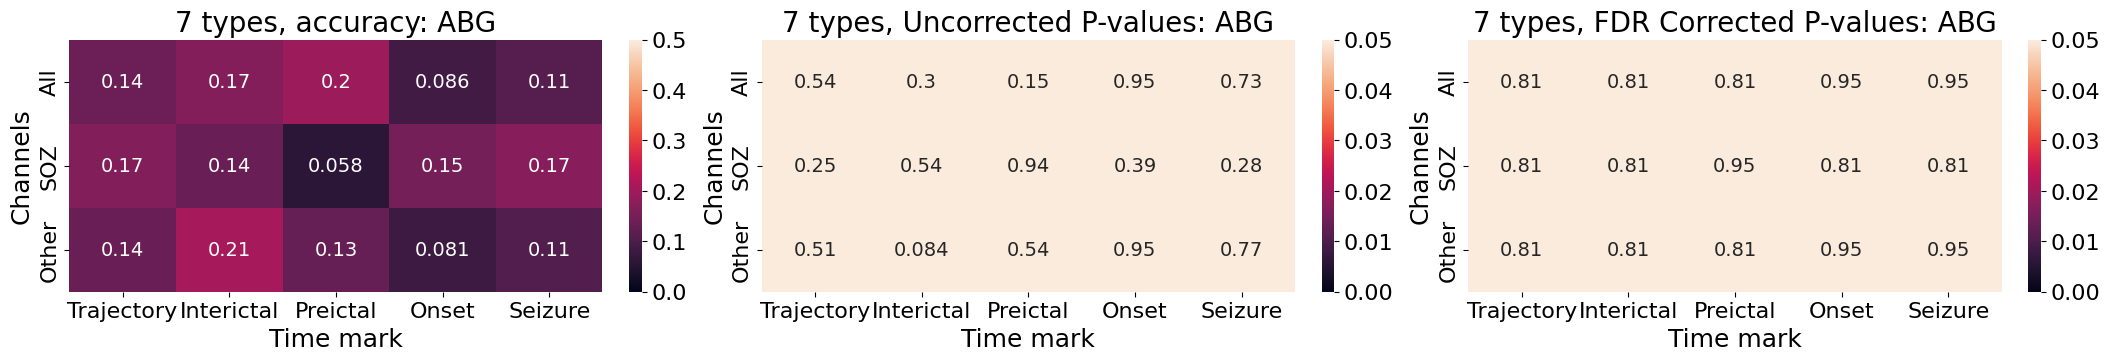

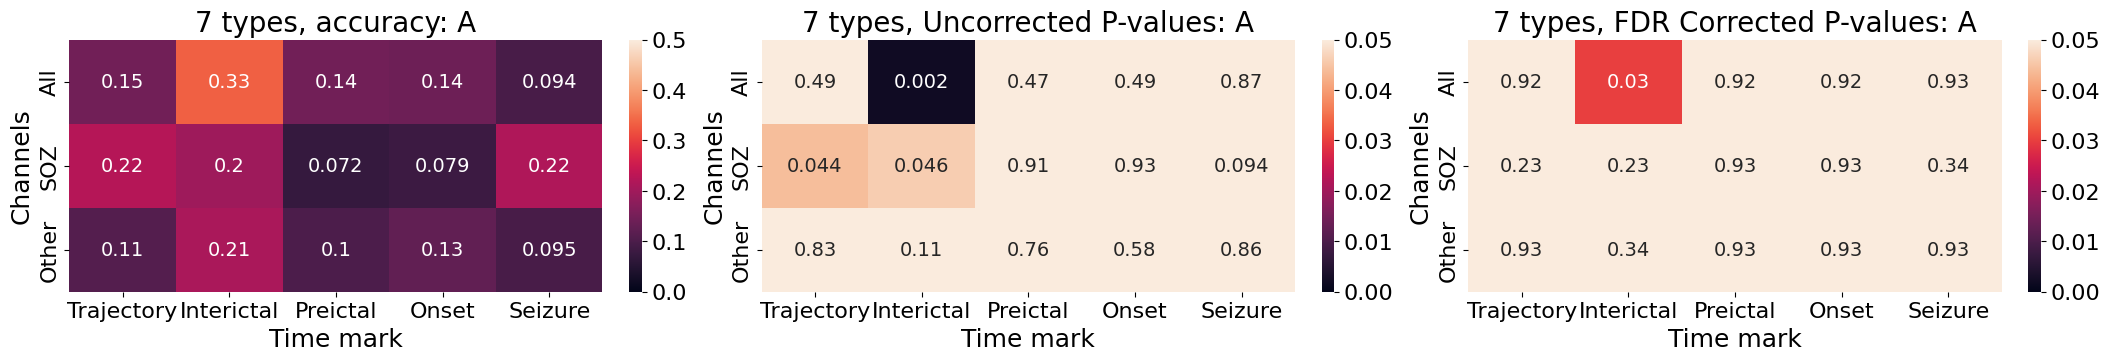

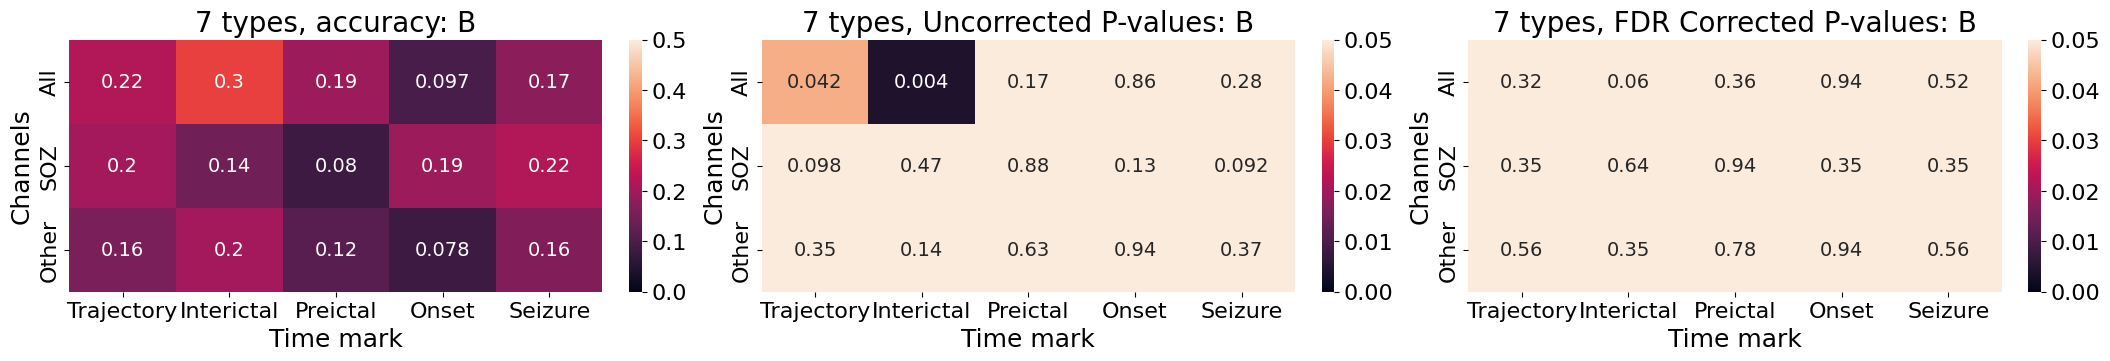

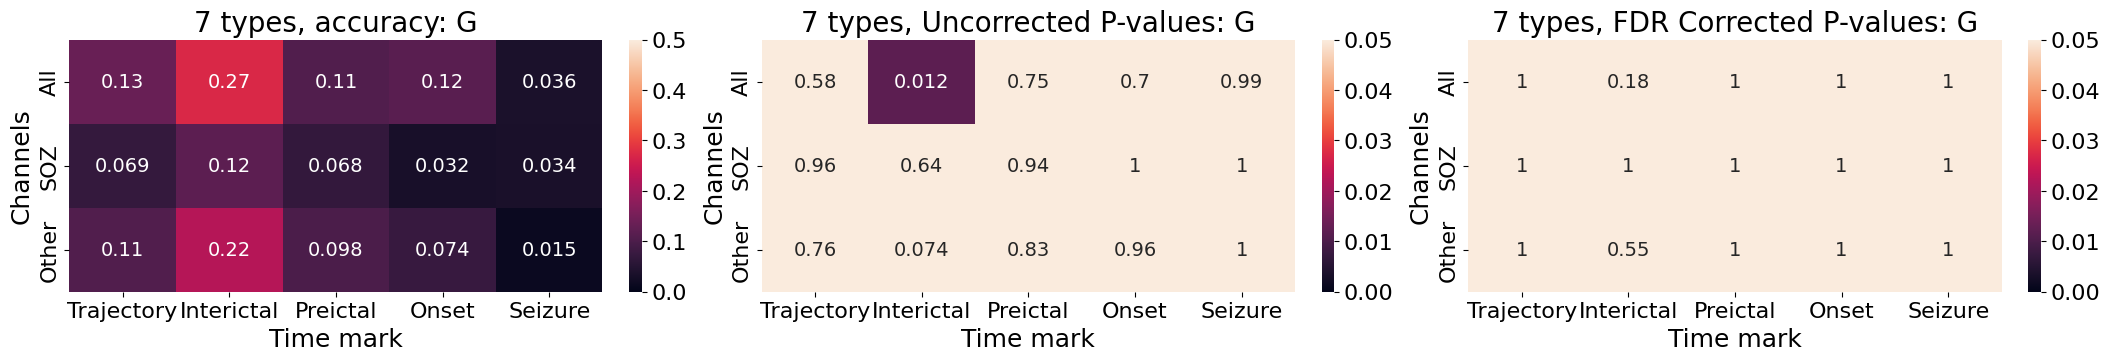

In [25]:
plt.rcParams.update({
    'font.size': 16,          # General font size (labels/ticks)
    'axes.titlesize': 20,      # Title size
    'axes.labelsize': 18,      # Axis labels size
    'xtick.labelsize': 16,     # X-axis tick labels
    'ytick.labelsize': 16      # Y-axis tick labels
})

nTypes = 7
for param in ['ABG', 'A', 'B', 'G']:
    fig = plt.figure(figsize=(21, 3.5), constrained_layout=True)
    grid = fig.add_gridspec(1, 3)

    ax1 = fig.add_subplot(grid[0,0])
    sns.heatmap(tables_accuracy[str(nTypes) + ' types, ' + param], annot=True,  vmin = 0, vmax=0.5, 
                annot_kws={"size": 14}) 
    plt.title(str(nTypes) + " types, accuracy: " + param)

    ax1 = fig.add_subplot(grid[0,1])
    sns.heatmap(tables_unc_p[str(nTypes) + ' types, ' + param], annot=True,  vmin = 0, vmax=0.05, 
                annot_kws={"size": 14}) 
    plt.title(str(nTypes) + " types, Uncorrected P-values: " + param)

    ax1 = fig.add_subplot(grid[0,2])
    sns.heatmap(tables_dfr_p[str(nTypes) + ' types, ' + param], annot=True,  vmin = 0, vmax=0.05, 
                annot_kws={"size": 14}) 
    plt.title(str(nTypes) + " types, FDR Corrected P-values: " + param)
    mark = str(nTypes) + 'types_' + param
    plt.savefig('../Pictures/Patterns/Classification_tables_'+mark+'_leavePatient.svg')
    plt.savefig('../Pictures/Patterns/Classification_tables_'+mark+'_leavePatient.png')
    plt.show()